In [33]:
# =========================================
# H1 (Experiment 1) - Recommended Analysis 2
# Long format (2 rows per participant: pre/post)
# Models:
#   Fpos ~ time * apology_type + scenario + (1|participant_id)
#   Fneg ~ time * apology_type + scenario + (1|participant_id)
# Includes:
#   - model fit (MixedLM)
#   - interaction tests (Wald)
#   - estimated marginal means (EMMs)
#   - bootstrap 95% CI for EMMs
#   - plots (95% CI + interaction visualization)
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from patsy import dmatrix

In [34]:
# -----------------------------
# 1) Load data
# -----------------------------
# Upload in Colab: Files > Upload, then set path below
path = "experiment1_long_time.xlsx"
df = pd.read_excel(path)

In [35]:
# Basic checks
required = ["participant_id", "scenario", "apology_type", "time", "Fpos", "Fneg"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

In [36]:
# Ensure categorical coding
df["participant_id"] = df["participant_id"].astype(str)
df["scenario"] = df["scenario"].astype("category")
df["apology_type"] = df["apology_type"].astype("category")

In [37]:
# Time should be ordered: pre, post
df["time"] = pd.Categorical(df["time"], categories=["pre", "post"], ordered=True)

In [38]:
# Optional: set reference level for apology_type (helps interpretation)
# Put healing as reference (so contrasts are vs healing)
# If your levels are different, adjust accordingly.
if "healing" in list(df["apology_type"].cat.categories):
    new_order = ["healing"] + [c for c in df["apology_type"].cat.categories if c != "healing"]
    df["apology_type"] = df["apology_type"].cat.reorder_categories(new_order, ordered=False)

print("Shape:", df.shape)
print(df[["participant_id","scenario","apology_type","time","Fpos","Fneg"]].head())

Shape: (356, 35)
  participant_id scenario apology_type time      Fpos      Fneg
0           P001        1      healing  pre  1.777778  4.222222
1           P002        1      healing  pre  7.000000  1.000000
2           P003        1      healing  pre  1.888889  4.000000
3           P004        1      healing  pre  1.444444  6.222222
4           P005        1      healing  pre  2.666667  4.222222


In [39]:
# -----------------------------
# 2) Fit MixedLM models
# -----------------------------
# Random intercept for participant_id
# Fixed effects: time * apology_type + scenario
formula_pos = "Fpos ~ time * apology_type + scenario"
formula_neg = "Fneg ~ time * apology_type + scenario"

In [40]:
import statsmodels.formula.api as smf

# Fpos 모델
ols_pos = smf.ols("Fpos ~ time * apology_type + scenario", data=df).fit(
    cov_type="cluster", cov_kwds={"groups": df["participant_id"]}
)

print(ols_pos.summary())

# Fneg 모델
ols_neg = smf.ols("Fneg ~ time * apology_type + scenario", data=df).fit(
    cov_type="cluster", cov_kwds={"groups": df["participant_id"]}
)

print(ols_neg.summary())

                            OLS Regression Results                            
Dep. Variable:                   Fpos   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.546
Method:                 Least Squares   F-statistic:                     131.3
Date:                Fri, 09 Jan 2026   Prob (F-statistic):           1.24e-66
Time:                        02:17:15   Log-Likelihood:                -552.75
No. Observations:                 356   AIC:                             1121.
Df Residuals:                     348   BIC:                             1152.
Df Model:                           7                                         
Covariance Type:              cluster                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

In [41]:
# -----------------------------
# 3) Wald tests for key interaction (time:apology_type)
# -----------------------------
def wald_test_interactions(result, prefix="time[T.post]:apology_type"):
    # Find interaction terms
    terms = [name for name in result.params.index if prefix in name]
    if not terms:
        print("No interaction terms found with prefix:", prefix)
        return None

    # Build restriction matrix R for joint test: all those interaction coefs = 0
    pnames = list(result.params.index)
    R = np.zeros((len(terms), len(pnames)))
    for i, t in enumerate(terms):
        R[i, pnames.index(t)] = 1.0

    wt = result.wald_test(R)
    print("\nWald test for joint interaction terms (time × apology_type):")
    print("Terms:", terms)
    print(wt)
    return wt

wt_pos = wald_test_interactions(ols_pos)
wt_neg = wald_test_interactions(ols_neg)


Wald test for joint interaction terms (time × apology_type):
Terms: ['time[T.post]:apology_type[T.defensive]', 'time[T.post]:apology_type[T.no_apology]']
<Wald test (chi2): statistic=[[261.9564356]], p-value=1.3088285477004612e-57, df_denom=2>

Wald test for joint interaction terms (time × apology_type):
Terms: ['time[T.post]:apology_type[T.defensive]', 'time[T.post]:apology_type[T.no_apology]']
<Wald test (chi2): statistic=[[141.48212077]], p-value=1.8947321830014604e-31, df_denom=2>


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


In [42]:
import os

# Save OLS results for Fpos
with open("OLS_Fpos_summary.txt", "w") as f:
    f.write(ols_pos.summary().as_text())

# Save OLS results for Fneg
with open("OLS_Fneg_summary.txt", "w") as f:
    f.write(ols_neg.summary().as_text())

print("OLS regression summaries saved as:")
print("- OLS_Fpos_summary.txt")
print("- OLS_Fneg_summary.txt")

OLS regression summaries saved as:
- OLS_Fpos_summary.txt
- OLS_Fneg_summary.txt


In [43]:
# -----------------------------
# 4) Estimated marginal means (EMMs)
#    We'll compute EMMs for each (apology_type, time), averaging over scenario.
# -----------------------------
def get_emm(result, df, dv_name):
    # Create grid for EMMs
    ap_levels = list(df["apology_type"].cat.categories)
    time_levels = list(df["time"].cat.categories)
    scen_levels = list(df["scenario"].cat.categories)

    grid = []
    for ap in ap_levels:
        for t in time_levels:
            for sc in scen_levels:
                grid.append({"apology_type": ap, "time": t, "scenario": sc})
    grid = pd.DataFrame(grid)

    # Use patsy to build design matrix matching the fitted model
    X = dmatrix(result.model.data.design_info.builder, grid, return_type="dataframe")

    # Predicted means for each row, then average over scenario
    pred = np.asarray(X @ result.params)
    grid["pred"] = pred

    emm = (
        grid.groupby(["apology_type", "time"], as_index=False)["pred"]
            .mean()
            .rename(columns={"pred": f"emm_{dv_name}"})
    )
    return emm

emm_pos = get_emm(ols_pos, df, "Fpos")
emm_neg = get_emm(ols_neg, df, "Fneg")

print("\nEMMs (averaged over scenario) - Fpos")
print(emm_pos)

print("\nEMMs (averaged over scenario) - Fneg")
print(emm_neg)


EMMs (averaged over scenario) - Fpos
  apology_type  time  emm_Fpos
0    defensive  post  3.374630
1    defensive   pre  3.440544
2      healing  post  5.700000
3      healing   pre  3.642593
4   no_apology  post  1.758621
5   no_apology   pre  3.510033

EMMs (averaged over scenario) - Fneg
  apology_type  time  emm_Fneg
0    defensive  post  4.624077
1    defensive   pre  4.183399
2      healing  post  2.287037
3      healing   pre  3.542593
4   no_apology  post  4.933516
5   no_apology   pre  3.634081


/tmp/ipython-input-2267010062.py:19: DeprecationWarning: The DesignInfo.builder attribute is deprecated starting in patsy v0.4.0; distinct builder objects have been eliminated and design_info.builder is now just a long-winded way of writing 'design_info' (i.e. the .builder attribute just returns self)
  X = dmatrix(result.model.data.design_info.builder, grid, return_type="dataframe")
/tmp/ipython-input-2267010062.py:19: DeprecationWarning: The DesignInfo.builder attribute is deprecated starting in patsy v0.4.0; distinct builder objects have been eliminated and design_info.builder is now just a long-winded way of writing 'design_info' (i.e. the .builder attribute just returns self)
  X = dmatrix(result.model.data.design_info.builder, grid, return_type="dataframe")


In [44]:
# -----------------------------
# 5) Bootstrap 95% CI for EMMs
#    Cluster bootstrap by participant_id (resample participants with replacement)
# -----------------------------
def bootstrap_emm(df, dv_col, formula, n_boot=2000, seed=123):
    rng = np.random.default_rng(seed)
    pids = df["participant_id"].unique()

    ap_levels = list(df["apology_type"].cat.categories)
    time_levels = list(df["time"].cat.categories)

    # Store bootstrap EMMs
    boot = {(ap, t): [] for ap in ap_levels for t in time_levels}

    for b in range(n_boot):
        sample_pids = rng.choice(pids, size=len(pids), replace=True)
        df_b = pd.concat([df[df["participant_id"] == pid] for pid in sample_pids], ignore_index=True)

        # Refit with OLS and clustered standard errors, consistent with previous steps
        try:
            # Changed from smf.mixedlm to smf.ols
            r = smf.ols(formula, data=df_b).fit(
                cov_type="cluster", cov_kwds={"groups": df_b["participant_id"]}
            )
        except Exception as e:
            # If fitting fails, skip this iteration
            print(f"Bootstrap fit failed for iteration {b}: {e}")
            continue

        # EMMs
        emm_b = get_emm(r, df_b, dv_col)
        for _, row in emm_b.iterrows():
            boot[(row["apology_type"], row["time"])].append(row[f"emm_{dv_col}"])

    # Summarize
    rows = []
    for (ap, t), vals in boot.items():
        vals = np.asarray(vals, dtype=float)
        vals = vals[~np.isnan(vals)]
        if len(vals) < 50:
            # too few successful bootstrap fits
            rows.append([ap, t, np.nan, np.nan, np.nan, len(vals)])
        else:
            rows.append([
                ap, t,
                np.mean(vals),
                np.percentile(vals, 2.5),
                np.percentile(vals, 97.5),
                len(vals)
            ])

    out = pd.DataFrame(rows, columns=["apology_type","time","mean","ci_low","ci_high","n_success"])
    return out

# NOTE: n_boot=2000 is good but can be slow in Colab.
# You can start with 500 for a quick check, then increase.
boot_pos = bootstrap_emm(df, "Fpos", formula_pos, n_boot=800, seed=1)
boot_neg = bootstrap_emm(df, "Fneg", formula_neg, n_boot=800, seed=2)

print("\nBootstrap EMMs + 95% CI (Fpos)")
print(boot_pos)

print("\nBootstrap EMMs + 95% CI (Fneg)")
print(boot_neg)

# Save bootstrap results
boot_pos.to_csv("H1_bootstrap_emm_Fpos.csv", index=False)
boot_neg.to_csv("H1_bootstrap_emm_Fneg.csv", index=False)

/tmp/ipython-input-2267010062.py:19: DeprecationWarning: The DesignInfo.builder attribute is deprecated starting in patsy v0.4.0; distinct builder objects have been eliminated and design_info.builder is now just a long-winded way of writing 'design_info' (i.e. the .builder attribute just returns self)
  X = dmatrix(result.model.data.design_info.builder, grid, return_type="dataframe")
/tmp/ipython-input-2267010062.py:19: DeprecationWarning: The DesignInfo.builder attribute is deprecated starting in patsy v0.4.0; distinct builder objects have been eliminated and design_info.builder is now just a long-winded way of writing 'design_info' (i.e. the .builder attribute just returns self)
  X = dmatrix(result.model.data.design_info.builder, grid, return_type="dataframe")
/tmp/ipython-input-2267010062.py:19: DeprecationWarning: The DesignInfo.builder attribute is deprecated starting in patsy v0.4.0; distinct builder objects have been eliminated and design_info.builder is now just a long-winded 


Bootstrap EMMs + 95% CI (Fpos)
  apology_type  time      mean    ci_low   ci_high  n_success
0      healing   pre  3.647938  3.295057  3.984640        800
1      healing  post  5.702761  5.476485  5.905595        800
2    defensive   pre  3.440486  3.165468  3.715626        800
3    defensive  post  3.372320  3.016653  3.752003        800
4   no_apology   pre  3.511131  3.231143  3.806225        800
5   no_apology  post  1.758490  1.555764  1.969146        800

Bootstrap EMMs + 95% CI (Fneg)
  apology_type  time      mean    ci_low   ci_high  n_success
0      healing   pre  3.548580  3.242786  3.870826        800
1      healing  post  2.286821  2.035424  2.545481        800
2    defensive   pre  4.193106  3.942356  4.437155        800
3    defensive  post  4.630470  4.271469  4.936888        800
4   no_apology   pre  3.630029  3.374554  3.939793        800
5   no_apology  post  4.930096  4.697011  5.187444        800


/tmp/ipython-input-2267010062.py:19: DeprecationWarning: The DesignInfo.builder attribute is deprecated starting in patsy v0.4.0; distinct builder objects have been eliminated and design_info.builder is now just a long-winded way of writing 'design_info' (i.e. the .builder attribute just returns self)
  X = dmatrix(result.model.data.design_info.builder, grid, return_type="dataframe")


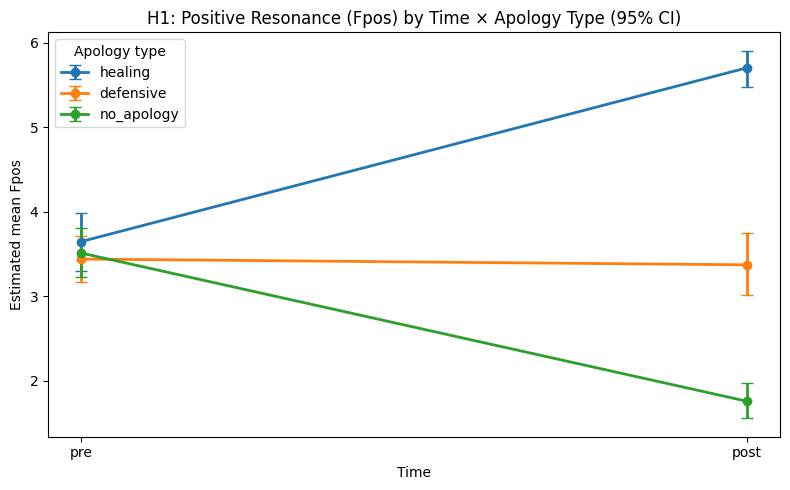

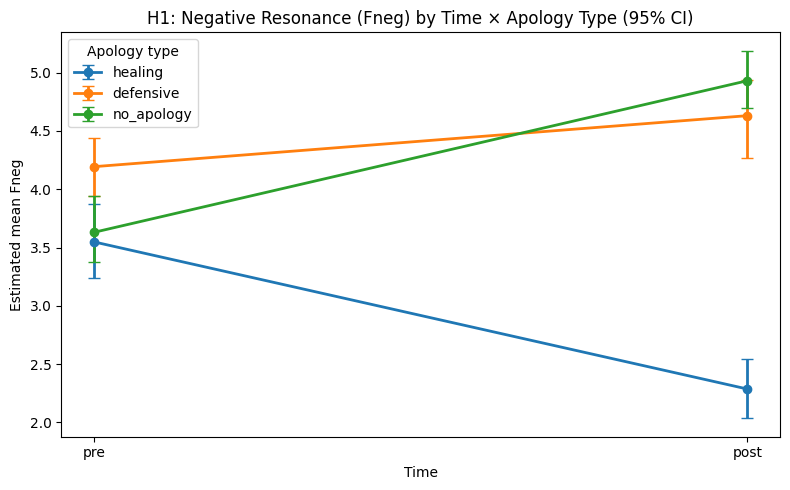


Saved files:
- H1_bootstrap_emm_Fpos.csv
- H1_bootstrap_emm_Fneg.csv
- H1_Fpos_time_by_type.png
- H1_Fneg_time_by_type.png


In [45]:
# -----------------------------
# 6) Plot: Interaction with 95% CI
# -----------------------------
def plot_emm_ci(boot_df, title, ylab, filename):
    ap_levels = list(boot_df["apology_type"].unique())
    time_levels = ["pre", "post"]

    x = np.arange(len(time_levels))

    plt.figure(figsize=(8,5))
    for ap in ap_levels:
        sub = boot_df[boot_df["apology_type"] == ap].copy()
        sub["time"] = pd.Categorical(sub["time"], categories=time_levels, ordered=True)
        sub = sub.sort_values("time")

        y = sub["mean"].values
        yerr_low = y - sub["ci_low"].values
        yerr_high = sub["ci_high"].values - y
        yerr = np.vstack([yerr_low, yerr_high])

        plt.errorbar(x, y, yerr=yerr, marker="o", capsize=4, linewidth=2, label=str(ap))

    plt.xticks(x, time_levels)
    plt.xlabel("Time")
    plt.ylabel(ylab)
    plt.title(title)
    plt.legend(title="Apology type")
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.show()

plot_emm_ci(
    boot_pos,
    title="H1: Positive Resonance (Fpos) by Time × Apology Type (95% CI)",
    ylab="Estimated mean Fpos",
    filename="H1_Fpos_time_by_type.png"
)

plot_emm_ci(
    boot_neg,
    title="H1: Negative Resonance (Fneg) by Time × Apology Type (95% CI)",
    ylab="Estimated mean Fneg",
    filename="H1_Fneg_time_by_type.png"
)

print("\nSaved files:")
print("- H1_bootstrap_emm_Fpos.csv")
print("- H1_bootstrap_emm_Fneg.csv")
print("- H1_Fpos_time_by_type.png")
print("- H1_Fneg_time_by_type.png")